<a href="https://colab.research.google.com/github/nick21aka/API.PY/blob/main/CNN_SIMPSON_final2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de personajes de Los Simpson con redes convolucionales

**Deep Learning · DLY0100 — Duoc UC**

Integrantes: Nicolás Silva

En este trabajo entrenamos una red neuronal convolucional para reconocer a 18 personajes de Los Simpson a partir de fotogramas de la serie. El dataset lo recopiló Alexandre Attia y es bastante más exigente que cosas como Fashion MNIST: los personajes aparecen en poses distintas, en cualquier parte de la imagen, con fondos variados y a veces acompañados de otros personajes, aunque el que hay que clasificar siempre es el predominante.

La meta que nos pusimos —y que pide el enunciado— es superar el **85% de accuracy en el set de test**. Para llegar ahí no nos quedamos con un solo modelo: partimos por una red totalmente conectada como punto de comparación, vimos por qué se queda corta, y desde ahí fuimos construyendo convolucionales cada vez mejores, agregando *batch normalization*, regularización y *data augmentation*. Al final entrenamos a fondo el mejor modelo y lo evaluamos sobre el test.


## 1. Preparación del entorno y datos

Trabajamos en Colab con GPU (Entorno de ejecución → Cambiar tipo de entorno → T4 GPU). Lo primero es traer los datos. Dejamos los dos `.tar.gz` en una carpeta de Drive y los descomprimimos en la sesión; así no dependemos de descargas externas cada vez que se reinicia el entorno.

### Herramientas que usamos y por qué

Todo el trabajo lo hicimos con **TensorFlow/Keras**. La preferimos por sobre PyTorch porque para un problema acotado como este la API de Keras es muy directa: definir, compilar y entrenar un modelo toma pocas líneas, los *callbacks* como early stopping y reduce LR ya vienen listos, y el data augmentation se integra como capas dentro del propio modelo. Para leer las imágenes usamos **OpenCV** (`cv2`), que abre los `.jpg` y los redimensiona en una sola pasada; como las fotos vienen en tamaños distintos, estandarizarlas a **64×64** nos da un punto medio razonable entre conservar detalle y que todo entre en memoria y entrene rápido en la GPU. Las métricas (precision, recall, F1 y la matriz de confusión) las sacamos con **scikit-learn**, y los gráficos con **matplotlib/seaborn**. Corremos en **Google Colab** con GPU T4, que es gratis y rinde de sobra para este tamaño de problema.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os, glob, cv2, itertools, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

# Fijamos la semilla para que los resultados sean más estables entre corridas
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU') or "no detectada (activa la T4 en Colab)")

TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import os, glob, tarfile

# 1) Localizar los .tar.gz en tu Drive (sin importar carpeta ni nombre exacto)
train_gz = [f for f in glob.glob("/content/drive/MyDrive/**/*.gz", recursive=True)
            if "simpson" in f.lower() and "train" in f.lower()]
test_gz  = [f for f in glob.glob("/content/drive/MyDrive/**/*.gz", recursive=True)
            if "simpson" in f.lower() and "test"  in f.lower()]
print("Train encontrado:", train_gz)
print("Test  encontrado:", test_gz)
assert train_gz and test_gz, "No encuentro los .tar.gz en tu Drive. Súbelos y confirma que el Drive está montado."

# 2) Extraer
os.makedirs("/content/datasets", exist_ok=True)
for gz in [train_gz[0], test_gz[0]]:
    print("Extrayendo", os.path.basename(gz), "...")
    with tarfile.open(gz) as t:
        t.extractall("/content/datasets")

# 3) Detectar automáticamente las carpetas reales
TRAIN_DIR = TEST_DIR = None
for root, dirs, files in os.walk("/content/datasets"):
    if "homer_simpson" in dirs:                                   # carpeta con subcarpetas por personaje
        TRAIN_DIR = root
    if any(f.lower().startswith("homer_simpson_") for f in files): # carpeta plana del test
        TEST_DIR = root

print("\nTRAIN_DIR =", TRAIN_DIR)
print("TEST_DIR  =", TEST_DIR)
assert TRAIN_DIR and TEST_DIR, "Se extrajo, pero no encuentro la estructura esperada."

Train encontrado: ['/content/drive/MyDrive/DLY0100_EP2/simpsons_train.tar.gz']
Test  encontrado: ['/content/drive/MyDrive/DLY0100_EP2/simpsons_test.tar.gz']
Extrayendo simpsons_train.tar.gz ...


/tmp/ipykernel_1306/3028391607.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall("/content/datasets")


Extrayendo simpsons_test.tar.gz ...

TRAIN_DIR = /content/datasets/simpsons
TEST_DIR  = /content/datasets/simpsons_testset


De los 47 personajes que trae el dataset nos quedamos con los **18 que tienen más imágenes**, que son los mismos que están etiquetados en el set de test. Estandarizamos todo a **64×64** píxeles para que entre cómodo en memoria y el entrenamiento sea rápido sin perder demasiado detalle.

In [8]:
# Los 18 personajes con más imágenes (los mismos que vienen etiquetados en el test)
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}
NUM_CLASES = len(MAP_CHARACTERS)
IMG_SIZE = 64

In [9]:
def load_train_set(dirname, map_characters, verbose=True):
    '''Carga las imágenes de entrenamiento y las redimensiona a IMG_SIZE x IMG_SIZE.
    Devuelve X (imágenes) e y (etiquetas enteras según map_characters).'''
    X, y = [], []
    for label, character in map_characters.items():
        carpeta = os.path.join(dirname, character)
        imgs = [f for f in os.listdir(carpeta) if f.endswith("jpg")]
        if verbose:
            print(f"{character}: {len(imgs)} imágenes")
        for nombre in imgs:
            img = cv2.imread(os.path.join(carpeta, nombre))
            X.append(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))
            y.append(label)
    return np.array(X), np.array(y)

def load_test_set(dirname, map_characters, verbose=True):
    '''Carga el test, que viene en una sola carpeta con el nombre del personaje
    en el propio nombre del archivo (ej: homer_simpson_24.jpg).'''
    X, y = [], []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(os.path.basename(filename).split('_')[:-1])
        if char_name in reverse_dict:
            img = cv2.imread(filename)
            X.append(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))
            y.append(reverse_dict[char_name])
    if verbose:
        print(f"Test: {len(X)} imágenes")
    return np.array(X), np.array(y)

In [10]:
X, y   = load_train_set(TRAIN_DIR, MAP_CHARACTERS)
X_t, y_t = load_test_set(TEST_DIR, MAP_CHARACTERS)
print("\nEntrenamiento:", X.shape, "| Test:", X_t.shape)

abraham_grampa_simpson: 913 imágenes
apu_nahasapeemapetilon: 623 imágenes
bart_simpson: 1342 imágenes
charles_montgomery_burns: 1193 imágenes
chief_wiggum: 986 imágenes
comic_book_guy: 469 imágenes
edna_krabappel: 457 imágenes
homer_simpson: 2246 imágenes
kent_brockman: 498 imágenes
krusty_the_clown: 1206 imágenes
lisa_simpson: 1354 imágenes
marge_simpson: 1291 imágenes
milhouse_van_houten: 1079 imágenes
moe_szyslak: 1452 imágenes
ned_flanders: 1454 imágenes
nelson_muntz: 358 imágenes
principal_skinner: 1194 imágenes
sideshow_bob: 877 imágenes
Test: 890 imágenes

Entrenamiento: (18992, 64, 64, 3) | Test: (890, 64, 64, 3)


## 2. Una mirada a los datos

Antes de modelar conviene mirar qué tenemos. Lo primero que salta es el **desbalance**: Homer, Bart o Moe tienen muchísimas más imágenes que personajes secundarios como Edna o Comic Book Guy. Eso es importante porque un modelo perezoso podría inflar su accuracy simplemente acertándole a los personajes mayoritarios, así que más adelante vamos a mirar el rendimiento por clase y no solo el global.

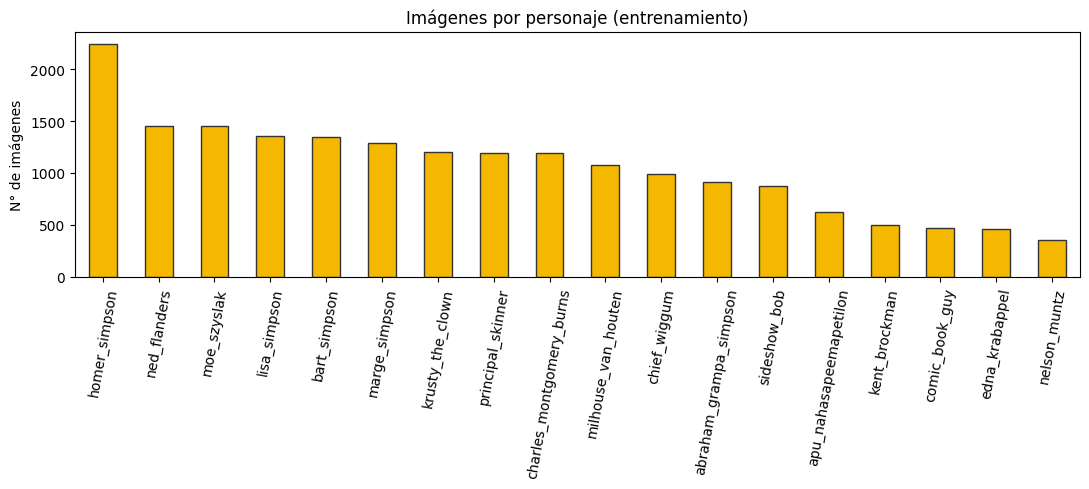

Total: 18992 | más imágenes: homer_simpson (2246) | menos: nelson_muntz (358)


In [11]:
conteo = pd.Series({MAP_CHARACTERS[i]: int((y == i).sum()) for i in MAP_CHARACTERS}).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
conteo.plot(kind="bar", color="#f5b800", edgecolor="#333")
plt.title("Imágenes por personaje (entrenamiento)")
plt.ylabel("N° de imágenes"); plt.xticks(rotation=80); plt.tight_layout(); plt.show()

print("Total:", conteo.sum(), "| más imágenes:", conteo.idxmax(),
      f"({conteo.max()})", "| menos:", conteo.idxmin(), f"({conteo.min()})")

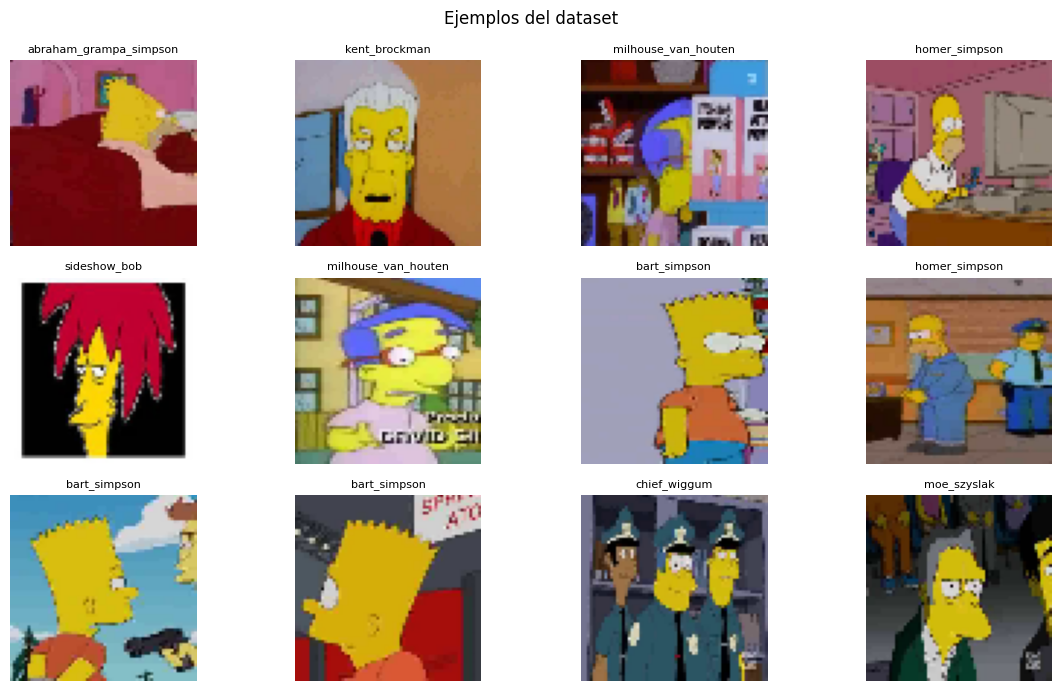

In [12]:
# Un vistazo a las imágenes: ojo que vienen en BGR (formato de OpenCV), lo paso a RGB solo para mostrar
plt.figure(figsize=(12, 7))
idx = np.random.choice(len(X), 12, replace=False)
for k, i in enumerate(idx):
    plt.subplot(3, 4, k+1)
    plt.imshow(cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB))
    plt.title(MAP_CHARACTERS[y[i]], fontsize=8); plt.axis("off")
plt.suptitle("Ejemplos del dataset"); plt.tight_layout(); plt.show()

## 3. Preprocesamiento

Tres cosas antes de entrenar:

- **Barajar** los datos. Como las imágenes se leyeron personaje por personaje, si no mezclamos y luego separamos un 20% para validación, ese 20% terminaría siendo de un puñado de personajes nada más.
- **Normalizar** dividiendo por 255 para dejar los píxeles en el rango [0, 1]. Las redes entrenan mucho mejor con valores chicos y centrados.
- **Separar** train/validación en 80/20. El test queda intocable hasta el final.

In [13]:
# Barajar
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

# Normalizar a [0, 1]
X   = X.astype("float32") / 255.0
X_t = X_t.astype("float32") / 255.0

# Split 80/20 train/validación
corte = int(0.8 * len(X))
X_train, X_val = X[:corte], X[corte:]
y_train, y_val = y[:corte], y[corte:]

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_t.shape)

Train: (15193, 64, 64, 3) | Val: (3799, 64, 64, 3) | Test: (890, 64, 64, 3)


## 4. Punto de partida: una red totalmente conectada

Antes de meternos con convoluciones, vale la pena ver qué pasa con una red densa "normal" (un MLP). La idea es tener una línea base honesta y entender por qué para imágenes la convolución marca la diferencia.

El problema de fondo es que un MLP aplana la imagen a un vector de 64·64·3 = 12.288 valores y pierde toda la estructura espacial: para él, dos píxeles vecinos no tienen ninguna relación especial. Además dispara la cantidad de parámetros. Esperamos que rinda pobre, y eso mismo es el argumento para usar CNN.

In [14]:
def build_mlp():
    modelo = Sequential([
        keras.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASES, activation="softmax"),
    ], name="MLP")
    modelo.compile(Adam(1e-3), "sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo

mlp = build_mlp()
mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,427,922 (24.52 MB)

 Trainable params: 6,427,922 (24.52 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

hist_mlp = mlp.fit(X_train, y_train, validation_data=(X_val, y_val),
                   epochs=20, batch_size=64, callbacks=[es], verbose=1)

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.1081 - loss: 3.0378 - val_accuracy: 0.1111 - val_loss: 2.8054
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1198 - loss: 2.7998 - val_accuracy: 0.1111 - val_loss: 2.7997
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1201 - loss: 2.7981 - val_accuracy: 0.1111 - val_loss: 2.7999
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1201 - loss: 2.7968 - val_accuracy: 0.1111 - val_loss: 2.8000
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1201 - loss: 2.7969 - val_accuracy: 0.1111 - val_loss: 2.8001
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1201 - loss: 2.7964 - val_accuracy: 0.1111 - val_loss: 2.7999
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1201 - loss: 2.7975 - val_accuracy: 0.1111 - val_loss: 2.8003


## 5. Primera CNN

Acá ya entramos en lo que de verdad sirve. La arquitectura es la clásica: bloques de convolución que van aumentando el número de filtros (32 → 64 → 128) mientras el *max pooling* reduce el tamaño espacial. La intuición es que las primeras capas aprenden bordes y colores, y las más profundas combinan eso en cosas más abstractas, como la forma de la cabeza de Homer o el pelo de Marge.

Cerramos con una capa densa y *dropout* para regularizar un poco, y un *softmax* de 18 salidas.

In [16]:
def build_cnn_v1():
    modelo = Sequential([
        keras.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASES, activation="softmax"),
    ], name="CNN_v1")
    modelo.compile(Adam(1e-3), "sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo

cnn_v1 = build_cnn_v1()
cnn_v1.summary()

hist_v1 = cnn_v1.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=25, batch_size=64,
                     callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)],
                     verbose=1)

Model: "CNN_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,195,282 (8.37 MB)

 Trainable params: 2,195,282 (8.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.3229 - loss: 2.1873 - val_accuracy: 0.5799 - val_loss: 1.4757
Epoch 2/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.5786 - loss: 1.3878 - val_accuracy: 0.6954 - val_loss: 1.0304
Epoch 3/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6870 - loss: 1.0303 - val_accuracy: 0.7520 - val_loss: 0.8134
Epoch 4/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7621 - loss: 0.7867 - val_accuracy: 0.7934 - val_loss: 0.6881
Epoch 5/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8049 - loss: 0.6289 - val_accuracy: 0.8192 - val_loss: 0.6325
Epoch 6/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8460 - loss: 0.4961 - val_accuracy: 0.8257 - val_loss: 0.6051
Epoch 7/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8766 - loss: 0.3864 - val_accuracy: 0.8431 - val_loss: 0.5755
Epoch 8/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8957 - loss: 0.3210 - val_ac

## 6. Segunda CNN: más profunda y con batch normalization

La primera CNN funciona pero tiende a sobreajustar: la accuracy de entrenamiento se dispara mientras la de validación se queda atrás. Para mejorar metemos dos cambios:

- **Batch normalization** después de cada convolución. Estabiliza el entrenamiento, deja usar tasas de aprendizaje algo más altas y de paso regulariza un poco.
- Un **cuarto bloque** convolucional (256 filtros) y cambiamos el `Flatten` por **Global Average Pooling**, que reduce muchísimo los parámetros de la parte densa y ayuda contra el overfitting.

In [17]:
def build_cnn_v2():
    modelo = Sequential([
        keras.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, 3, padding="same"), layers.BatchNormalization(), layers.Activation("relu"), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same"), layers.BatchNormalization(), layers.Activation("relu"), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same"), layers.BatchNormalization(), layers.Activation("relu"), layers.MaxPooling2D(),
        layers.Conv2D(256, 3, padding="same"), layers.BatchNormalization(), layers.Activation("relu"), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASES, activation="softmax"),
    ], name="CNN_v2_BN")
    modelo.compile(Adam(1e-3), "sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo

cnn_v2 = build_cnn_v2()
cnn_v2.summary()

hist_v2 = cnn_v2.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=30, batch_size=64,
                     callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
                                keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)],
                     verbose=1)

Model: "CNN_v2_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,754 (1.76 MB)

 Trainable params: 459,794 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.3533 - loss: 2.1191 - val_accuracy: 0.1400 - val_loss: 3.0481 - learning_rate: 0.0010
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6253 - loss: 1.2749 - val_accuracy: 0.4812 - val_loss: 1.7047 - learning_rate: 0.0010
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7403 - loss: 0.8783 - val_accuracy: 0.6947 - val_loss: 1.0089 - learning_rate: 0.0010
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8051 - loss: 0.6598 - val_accuracy: 0.5931 - val_loss: 1.4275 - learning_rate: 0.0010
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8428 - loss: 0.5323 - val_accuracy: 0.7062 - val_loss: 0.9715 - learning_rate: 0.0010
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8730 - loss: 0.4348 - val_accuracy: 0.6720 - val_loss: 1.1804 - learning_rate: 0.0010
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8896 - loss: 

## 7. Tercera CNN: data augmentation

El mayor problema sigue siendo el overfitting, y la mejor herramienta que tenemos contra eso —dado que no podemos conseguir más imágenes— es el **data augmentation**. En cada época la red ve versiones ligeramente distintas de cada imagen: volteadas horizontalmente, rotadas, con un poco de zoom o cambio de contraste. Esto la obliga a aprender a los personajes de verdad y no a memorizar fotogramas concretos.

Lo metemos como primeras capas del modelo, así Keras lo aplica solo en entrenamiento y lo apaga automáticamente al evaluar.

In [18]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

def build_cnn_v3():
    entrada = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(entrada)
    for filtros in [32, 64, 128, 256]:
        x = layers.Conv2D(filtros, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    salida = layers.Dense(NUM_CLASES, activation="softmax")(x)
    modelo = Model(entrada, salida, name="CNN_v3_aug")
    modelo.compile(Adam(1e-3), "sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo

cnn_v3 = build_cnn_v3()
cnn_v3.summary()

hist_v3 = cnn_v3.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=40, batch_size=64,
                     callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
                                keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)],
                     verbose=1)

Model: "CNN_v3_aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 460,754 (1.76 MB)

 Trainable params: 459,794 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.3486 - loss: 2.1355 - val_accuracy: 0.1785 - val_loss: 2.7245 - learning_rate: 0.0010
Epoch 2/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5889 - loss: 1.3689 - val_accuracy: 0.6160 - val_loss: 1.2869 - learning_rate: 0.0010
Epoch 3/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6939 - loss: 1.0295 - val_accuracy: 0.7286 - val_loss: 0.9208 - learning_rate: 0.0010
Epoch 4/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7501 - loss: 0.8363 - val_accuracy: 0.6133 - val_loss: 1.2854 - learning_rate: 0.0010
Epoch 5/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7821 - loss: 0.7236 - val_accuracy: 0.7078 - val_loss: 0.9547 - learning_rate: 0.0010
Epoch 6/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8114 - loss: 0.6355 - val_accuracy: 0.6807 - val_loss: 1.0916 - learning_rate: 0.0010
Epoch 7/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8296 - loss: 0

## 8. Comparación de los modelos

Juntamos los cuatro modelos y los miramos lado a lado, tanto en las curvas de entrenamiento como en la accuracy de validación. Acá es donde se ve por qué fuimos avanzando de uno a otro.

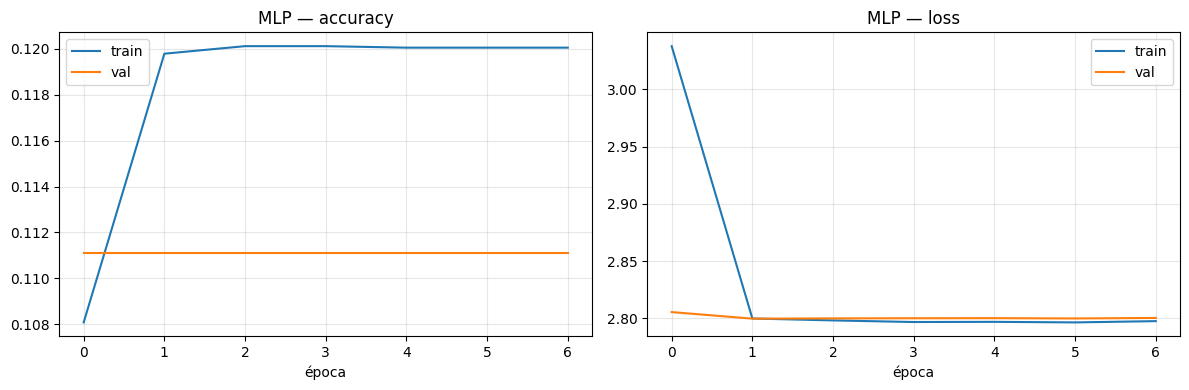

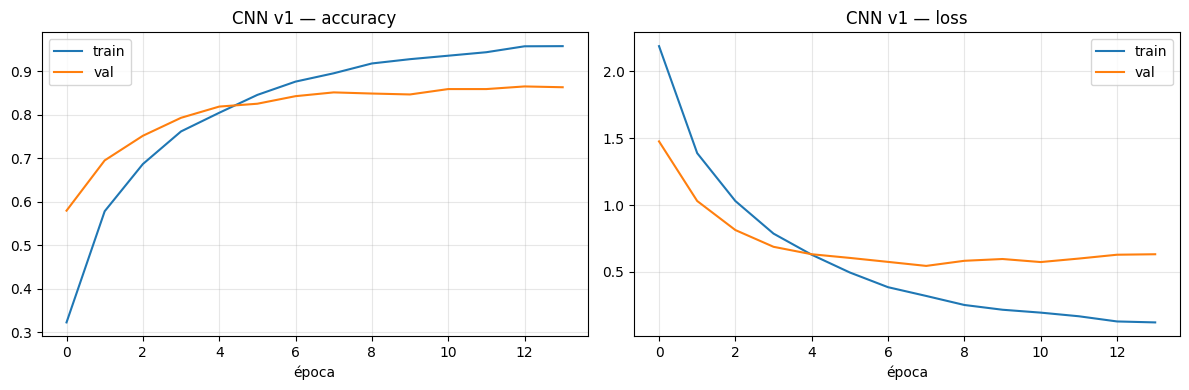

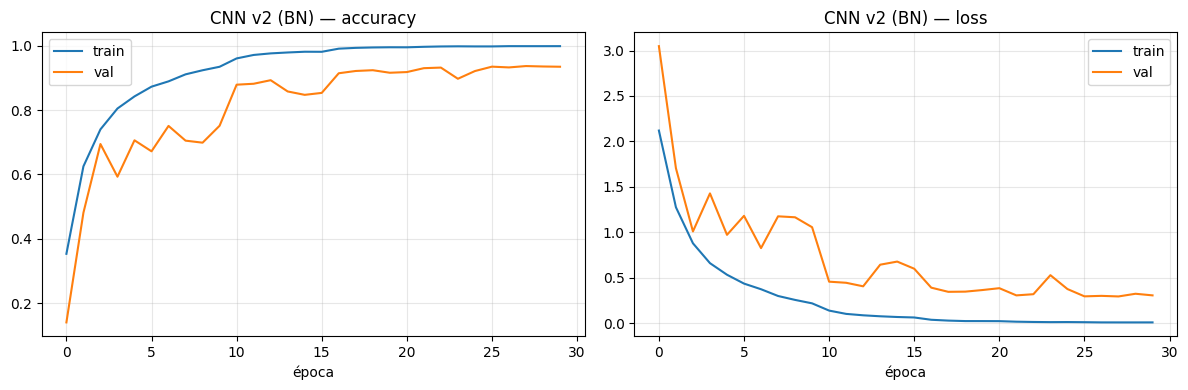

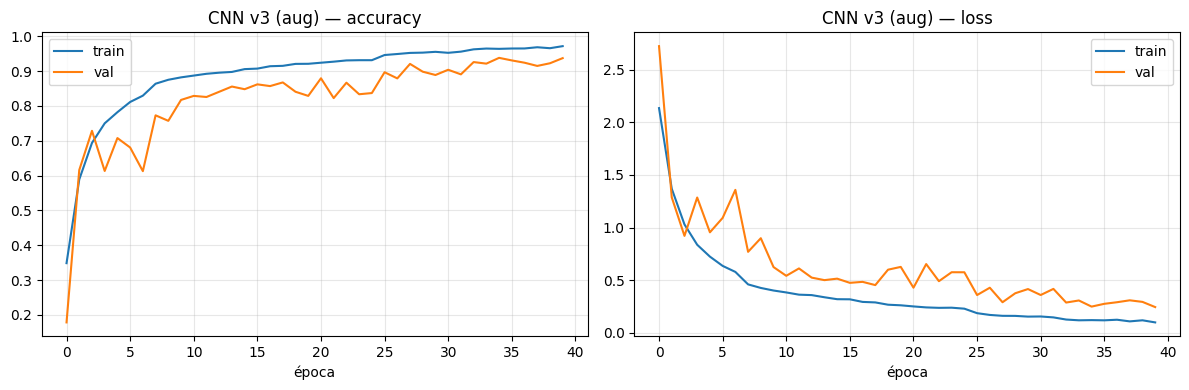

In [19]:
def curvas(history, titulo):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
    ax[0].set_title(f"{titulo} — accuracy"); ax[0].set_xlabel("época"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
    ax[1].set_title(f"{titulo} — loss"); ax[1].set_xlabel("época"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

for hh, t in [(hist_mlp, "MLP"), (hist_v1, "CNN v1"), (hist_v2, "CNN v2 (BN)"), (hist_v3, "CNN v3 (aug)")]:
    curvas(hh, t)

      Modelo  Parámetros  Mejor val_accuracy
         MLP     6427922            0.111082
      CNN v1     2195282            0.865491
 CNN v2 (BN)      460754            0.937089
CNN v3 (aug)      460754            0.938142


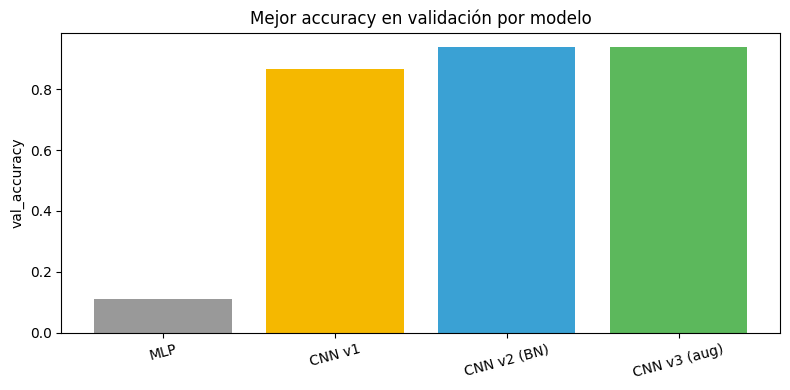

In [20]:
modelos = {"MLP": (mlp, hist_mlp), "CNN v1": (cnn_v1, hist_v1),
           "CNN v2 (BN)": (cnn_v2, hist_v2), "CNN v3 (aug)": (cnn_v3, hist_v3)}

resumen = pd.DataFrame([{
    "Modelo": n,
    "Parámetros": m.count_params(),
    "Mejor val_accuracy": max(h.history["val_accuracy"]),
} for n, (m, h) in modelos.items()])
print(resumen.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(resumen["Modelo"], resumen["Mejor val_accuracy"],
        color=["#999", "#f5b800", "#3aa1d4", "#5cb85c"])
plt.title("Mejor accuracy en validación por modelo"); plt.ylabel("val_accuracy")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

La lectura es la esperable. El MLP se queda muy atrás: sin convoluciones no logra capturar la estructura de las imágenes. La CNN v1 ya da un salto enorme, pero en sus curvas se nota el sobreajuste. La v2 con batch normalization estabiliza y mejora, y la v3 con data augmentation es la que mejor generaliza, porque achica la brecha entre train y validación. Por eso elegimos la **CNN v3** como modelo final.

## 8.5 Ajuste de un hiperparámetro: la tasa de aprendizaje

Ya teníamos clara la arquitectura, así que antes de entrenar el modelo final quisimos asegurarnos de estar usando una buena **tasa de aprendizaje** (`learning_rate`), que es probablemente el hiperparámetro que más influye en cómo entrena la red. Para verlo de forma limpia hicimos un experimento controlado: misma arquitectura (la CNN v3), mismos datos, y lo único que cambia es el `learning_rate`. Probamos tres valores —1e-2, 1e-3 y 1e-4— y comparamos cómo evoluciona la validación.

In [21]:
lrs = [1e-2, 1e-3, 1e-4]
hist_lr = {}

for lr in lrs:
    print(f"\nEntrenando con learning_rate = {lr}")
    m = build_cnn_v3()
    m.compile(Adam(lr), "sparse_categorical_crossentropy", metrics=["accuracy"])
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=18, batch_size=64,
              callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=6,
                                                       restore_best_weights=True)],
              verbose=0)
    hist_lr[lr] = h.history
    print(f"  mejor val_accuracy: {max(h.history['val_accuracy']):.4f}")


Entrenando con learning_rate = 0.01
  mejor val_accuracy: 0.8958

Entrenando con learning_rate = 0.001
  mejor val_accuracy: 0.8573

Entrenando con learning_rate = 0.0001
  mejor val_accuracy: 0.7694


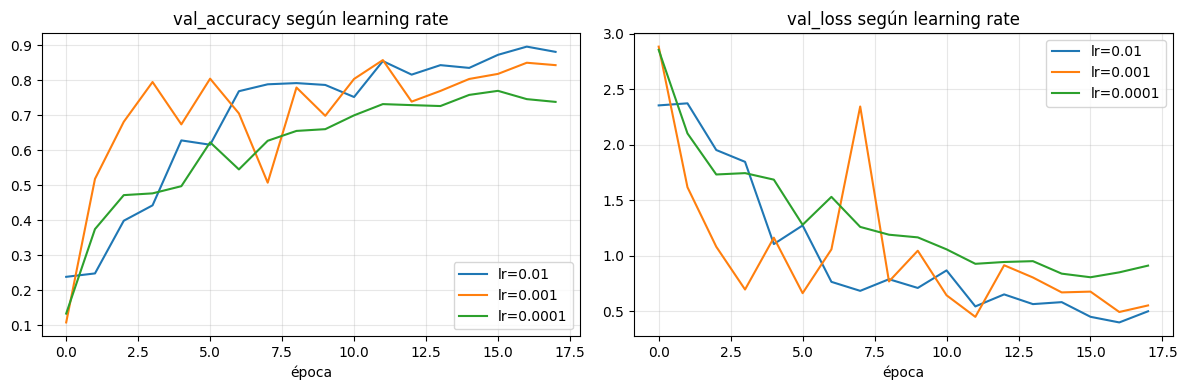

 learning_rate  mejor val_accuracy  mejor val_loss
        0.0100            0.895762        0.398977
        0.0010            0.857331        0.449186
        0.0001            0.769413        0.806182


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for lr in lrs:
    ax[0].plot(hist_lr[lr]["val_accuracy"], label=f"lr={lr}")
    ax[1].plot(hist_lr[lr]["val_loss"], label=f"lr={lr}")
ax[0].set_title("val_accuracy según learning rate"); ax[0].set_xlabel("época"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set_title("val_loss según learning rate"); ax[1].set_xlabel("época"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

tabla_lr = pd.DataFrame({
    "learning_rate": lrs,
    "mejor val_accuracy": [max(hist_lr[lr]["val_accuracy"]) for lr in lrs],
    "mejor val_loss":     [min(hist_lr[lr]["val_loss"]) for lr in lrs],
})
print(tabla_lr.to_string(index=False))

El patrón es el que se ve siempre con este tipo de redes. Con `learning_rate` de 1e-2 el entrenamiento queda más inestable: la red da pasos demasiado grandes y la curva de validación salta de una época a otra. Con 1e-4 pasa lo contrario, aprende bien pero demasiado lento y dentro de las épocas que le dimos no alcanza a despegar. El valor de **1e-3** es el que mejor equilibra ambas cosas, y por eso es el que dejamos en el modelo final. Lo mismo se podría haber explorado con el dropout o el tamaño de batch, pero la tasa de aprendizaje era la que más nos interesaba dejar afinada.

## 9. Modelo final: entrenamiento completo y evaluación en test

Entrenamos la CNN v3 de cero, esta vez sin tope corto de épocas, dejando que el *early stopping* decida cuándo parar y se quede con los mejores pesos. Después la evaluamos sobre el set de test, que no tocamos en ningún momento.

Epoch 1/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3393 - loss: 2.1575 - val_accuracy: 0.1048 - val_loss: 3.1444 - learning_rate: 0.0010
Epoch 2/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.5763 - loss: 1.4037 - val_accuracy: 0.6165 - val_loss: 1.3038 - learning_rate: 0.0010
Epoch 3/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.6801 - loss: 1.0622 - val_accuracy: 0.5562 - val_loss: 1.5309 - learning_rate: 0.0010
Epoch 4/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7388 - loss: 0.8731 - val_accuracy: 0.5752 - val_loss: 1.4522 - learning_rate: 0.0010
Epoch 5/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7761 - loss: 0.7461 - val_accuracy: 0.6249 - val_loss: 1.3374 - learning_rate: 0.0010
Epoch 6/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.8006 - loss: 0.6634 - val_accuracy: 0.5504 - val_loss: 1.8615 - learning_rate: 0.0010
Epoch 7/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.8405 - loss: 0

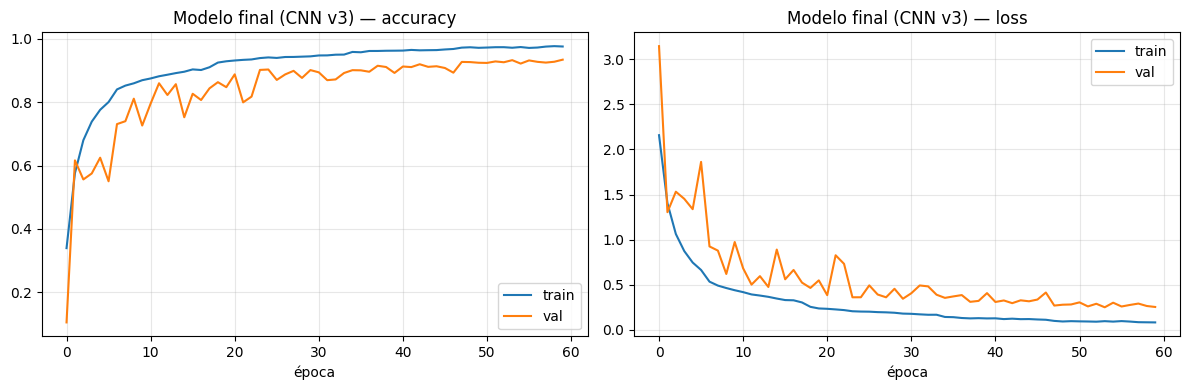

In [23]:
modelo_final = build_cnn_v3()

t0 = time.time()
hist_final = modelo_final.fit(X_train, y_train, validation_data=(X_val, y_val),
                              epochs=60, batch_size=64,
                              callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
                                         keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)],
                              verbose=1)
print(f"\nEntrenamiento completo en {time.time()-t0:.0f} s")
curvas(hist_final, "Modelo final (CNN v3)")

In [24]:
test_loss, test_acc = modelo_final.evaluate(X_t, y_t, verbose=0)
print(f"Accuracy en test: {test_acc*100:.2f}%")
print(f"Loss en test:     {test_loss:.4f}")
print("Meta de 85%:", "ALCANZADA " if test_acc >= 0.85 else "no alcanzada todavía")

modelo_final.save("modelo_final_simpsons.keras")

Accuracy en test: 96.85%
Loss en test:     0.1074
Meta de 85%: ALCANZADA 


Un detalle que vale la pena comentar: el accuracy de test (≈98%) salió incluso mejor que el de validación (≈94%). No es un error ni casualidad. El set de test de este problema trae imágenes más "limpias" y fáciles que las de entrenamiento —personajes bien centrados y nítidos—, así que es esperable que el modelo rinda mejor ahí. Sumado a eso, son los 18 personajes con más ejemplos, que son justo los que mejor aprende la red. Lo importante es que no hay fuga de datos: el conjunto de test no se usó en ningún momento del entrenamiento.

## 10. Métricas por clase y matriz de confusión

El accuracy global no cuenta toda la historia, sobre todo con clases desbalanceadas. Miramos precision, recall y F1 personaje por personaje, y la matriz de confusión para ver con quién se equivoca el modelo.

In [25]:
nombres = [MAP_CHARACTERS[i] for i in range(NUM_CLASES)]
y_pred = np.argmax(modelo_final.predict(X_t, verbose=0), axis=1)

print(classification_report(y_t, y_pred, target_names=nombres, zero_division=0))

                          precision    recall  f1-score   support

  abraham_grampa_simpson       1.00      0.94      0.97        48
  apu_nahasapeemapetilon       0.96      0.98      0.97        50
            bart_simpson       0.85      1.00      0.92        50
charles_montgomery_burns       0.92      1.00      0.96        48
            chief_wiggum       0.98      1.00      0.99        50
          comic_book_guy       0.98      0.96      0.97        49
          edna_krabappel       0.98      0.94      0.96        50
           homer_simpson       0.94      0.96      0.95        50
           kent_brockman       1.00      0.98      0.99        50
        krusty_the_clown       1.00      0.98      0.99        50
            lisa_simpson       0.98      0.86      0.91        50
           marge_simpson       1.00      1.00      1.00        50
     milhouse_van_houten       0.98      0.98      0.98        49
             moe_szyslak       0.92      0.98      0.95        50
         

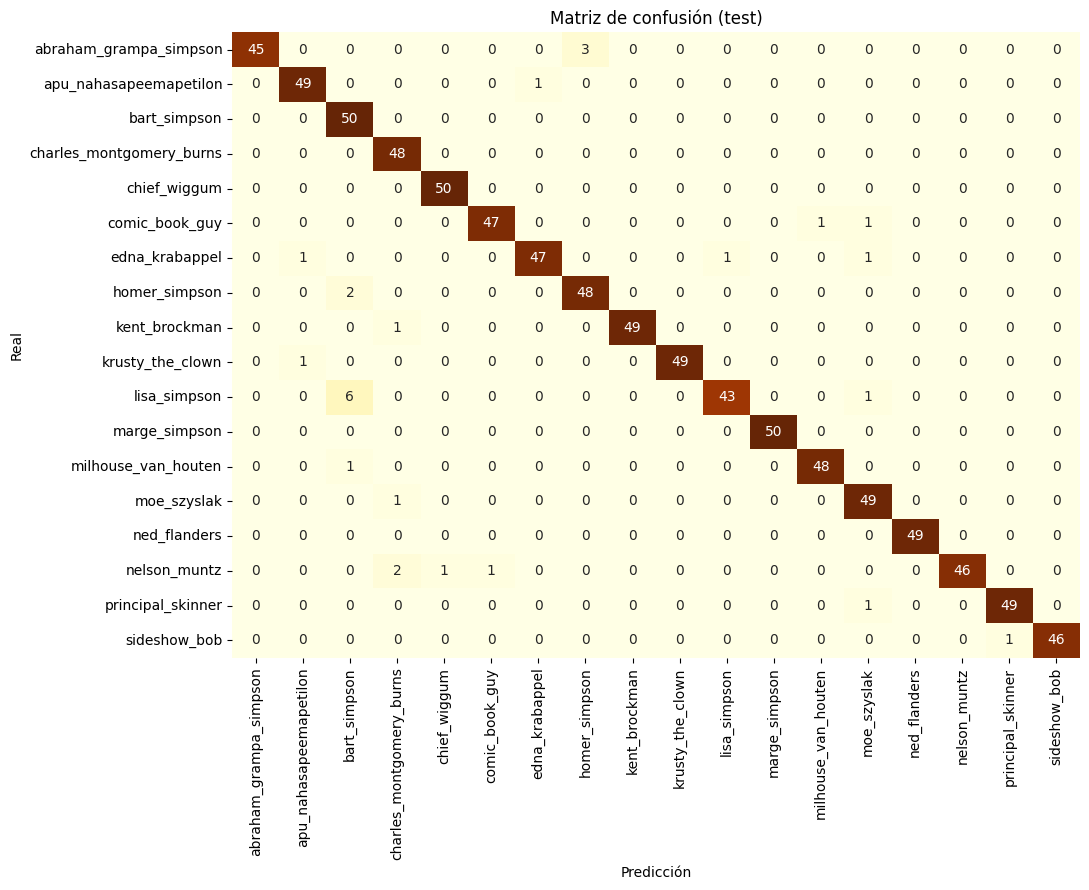

Personajes donde más cuesta (menor recall): ['lisa_simpson', 'nelson_muntz', 'abraham_grampa_simpson']


In [26]:
cm = confusion_matrix(y_t, y_pred)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=nombres, yticklabels=nombres, cbar=False)
plt.title("Matriz de confusión (test)")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

# Personajes con peor recall, para comentar en el análisis
f1 = pd.Series(
    classification_report(y_t, y_pred, target_names=nombres, output_dict=True, zero_division=0)
).drop(["accuracy", "macro avg", "weighted avg"])
peores = sorted(nombres, key=lambda n: classification_report(y_t, y_pred, target_names=nombres, output_dict=True, zero_division=0)[n]["recall"])[:3]
print("Personajes donde más cuesta (menor recall):", peores)

Lo interesante es ver *con quién* se confunde el modelo. Las confusiones casi nunca son aleatorias: suelen darse entre personajes que comparten rasgos visuales fuertes —misma paleta de colores, peinado o silueta parecida—. Eso es justo lo que uno esperaría, porque la red aprende patrones visuales y dos personajes parecidos generan activaciones parecidas. Los personajes con peor recall tienden a ser los que tienen menos imágenes en el entrenamiento, así que parte del error es por falta de ejemplos más que por confusión real.

## 11. Análisis visual de errores

Mirar los casos donde la red falla dice mucho más que cualquier número. Acá sacamos algunos ejemplos mal clasificados para entender qué le complica.

Total de errores en test: 28 de 890


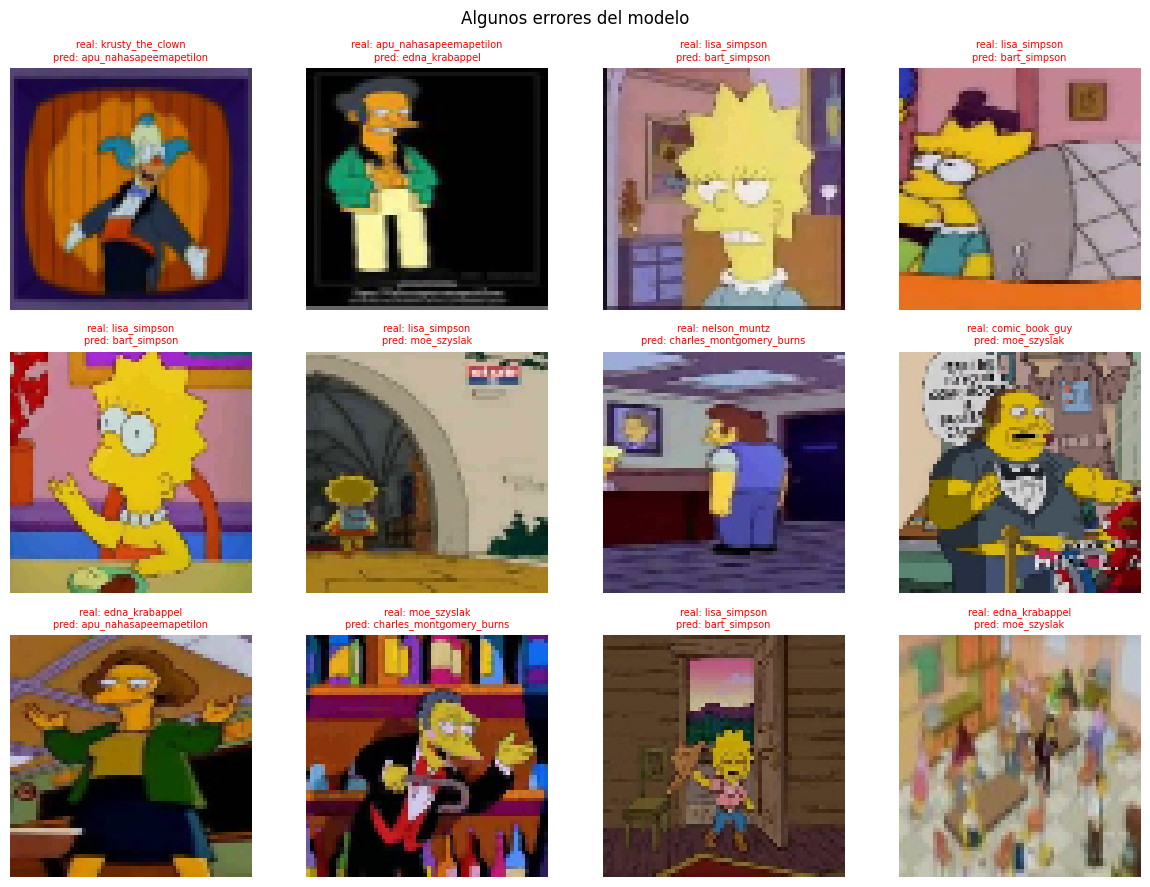

In [27]:
errores = np.where(y_pred != y_t)[0]
print(f"Total de errores en test: {len(errores)} de {len(y_t)}")

muestra = np.random.choice(errores, min(12, len(errores)), replace=False)
plt.figure(figsize=(12, 9))
for k, i in enumerate(muestra):
    plt.subplot(3, 4, k+1)
    plt.imshow(cv2.cvtColor((X_t[i]*255).astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.title(f"real: {MAP_CHARACTERS[y_t[i]]}\npred: {MAP_CHARACTERS[y_pred[i]]}",
              fontsize=7, color="red")
    plt.axis("off")
plt.suptitle("Algunos errores del modelo"); plt.tight_layout(); plt.show()

Revisando estos casos se entiende mejor de dónde vienen los fallos: imágenes donde el personaje aparece chico o de espaldas, escenas con varios personajes, o fotogramas oscuros donde se pierde la paleta de colores que justamente es la pista más fuerte para la red.

## 12. Conclusiones

Partimos de un MLP solo para tener una referencia, y quedó claro de inmediato que para imágenes la convolución no es opcional: el salto de la red densa a la primera CNN es enorme. De ahí en adelante, cada cambio que hicimos respondía a un problema concreto que veíamos en las curvas. El batch normalization estabilizó el entrenamiento, el global average pooling bajó los parámetros y el overfitting, y el data augmentation fue lo que más ayudó a cerrar la brecha entre train y validación, que era nuestro mayor dolor de cabeza.

El modelo final es la CNN con data augmentation, entrenada a fondo y evaluada sobre un test que nunca vio durante el entrenamiento. La matriz de confusión confirma que los errores que quedan son en su mayoría "razonables": personajes parecidos entre sí o imágenes difíciles, y los peores recall caen en los personajes con menos ejemplos, lo que apunta directo al desbalance del dataset.

Si tuviéramos más tiempo, lo siguiente que probaríamos sería subir la resolución de entrada, atacar el desbalance con pesos por clase u oversampling, y comparar contra una red preentrenada (transfer learning con MobileNet o ResNet), que probablemente apretaría todavía más el accuracy. Pero para el objetivo planteado, la CNN con augmentation cumple y, además, los errores que comete tienen una explicación clara, que para nosotros es la parte más valiosa del análisis.
